In [3]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import pandas as pd

x_train = pd.read_csv('x_train_final.csv')
y_train = pd.read_csv('y_train_final.csv')
x_test  = pd.read_csv('x_test_final.csv')

print(f"\nx_train: {x_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"x_test: {x_test.shape}")


x_train: (667264, 12)
y_train: (667264, 2)
x_test: (20657, 11)


In [4]:
# EDA
print("=== X_TRAIN ===")
print(f"Shape: {x_train.shape}")
print(f"Colonnes: {list(x_train.columns)}")
print(f"\nTypes:\n{x_train.dtypes}")
print(f"\nValeurs uniques:")
for col in x_train.columns:
    print(f"  {col}: {x_train[col].nunique()}")
print(f"\n{x_train.head()}")
print(f"\n{x_train.describe()}")

print("\n=== Y_TRAIN ===")
print(f"Shape: {y_train.shape}")
print(f"\n{y_train.describe()}")

print("\n=== X_TEST ===")
print(f"Shape: {x_test.shape}")
print(f"\n{x_test.head()}")

=== X_TRAIN ===
Shape: (667264, 12)
Colonnes: ['Unnamed: 0.1', 'Unnamed: 0', 'train', 'gare', 'date', 'arret', 'p2q0', 'p3q0', 'p4q0', 'p0q2', 'p0q3', 'p0q4']

Types:
Unnamed: 0.1      int64
Unnamed: 0        int64
train               str
gare                str
date                str
arret             int64
p2q0            float64
p3q0            float64
p4q0            float64
p0q2            float64
p0q3            float64
p0q4            float64
dtype: object

Valeurs uniques:
  Unnamed: 0.1: 667264
  Unnamed: 0: 667264
  train: 37544
  gare: 84
  date: 91
  arret: 36
  p2q0: 120
  p3q0: 123
  p4q0: 121
  p0q2: 121
  p0q3: 123
  p0q4: 123

   Unnamed: 0.1  Unnamed: 0   train gare        date  arret  p2q0  p3q0  p4q0  \
0             0           0  VBXNMF  KYF  2023-04-03      8   0.0   0.0   1.0   
1             1           1  VBXNMF  JLR  2023-04-03      9   0.0   0.0   0.0   
2             2           2  VBXNMF  EOH  2023-04-03     10  -1.0   0.0   0.0   
3             3        

In [5]:
# Pas de suppression d'outliers (comme le pote)
y = y_train["p0q0"]
print(f"y: {y.shape}")
print(f"\n{y.describe()}")

y: (667264,)

count    667264.000000
mean         -0.159950
std           1.987872
min        -160.000000
25%          -1.000000
50%           0.000000
75%           1.000000
max          15.000000
Name: p0q0, dtype: float64


In [6]:
import pandas as pd
import numpy as np
import networkx as nx
import copy
from sklearn.preprocessing import LabelEncoder

# ===== Concat train + test pour features communes =====
full = pd.concat([x_train, x_test], axis=0).reset_index(drop=True)
full = full.drop(columns=["Unnamed: 0", "Unnamed: 0.1"], errors="ignore")

full["date"] = pd.to_datetime(full["date"])

# ===== FEATURE ENGINEERING (même logique que le pote) =====
cols_retard_train = ["p2q0", "p3q0", "p4q0"]
cols_retard_gare  = ["p0q2", "p0q3", "p0q4"]
cols_all = cols_retard_train + cols_retard_gare

# Moyennes et écart-types
full["mean_retard_train"]  = full[cols_retard_train].mean(axis=1)
full["mean_retard_gare"]   = full[cols_retard_gare].mean(axis=1)
full["mean_retard_global"] = full[cols_all].mean(axis=1)
full["std_retard_train"]   = full[cols_retard_train].std(axis=1)
full["std_retard_gare"]    = full[cols_retard_gare].std(axis=1)

# Tendances
full["tendance_train"] = full["p2q0"] - full["p4q0"]
full["tendance_gare"]  = full["p0q2"] - full["p0q4"]

# Extrêmes
full["max_retard"] = full[cols_all].max(axis=1)
full["min_retard"] = full[cols_all].min(axis=1)

# ===== Position moyenne de la gare dans le trajet =====
train_part = full.iloc[:len(y)]
position_gare = {}
for (train_id, date), groupe in train_part.groupby(["train", "date"]):
    groupe = groupe.sort_values("arret")
    n = len(groupe)
    for i, (_, row) in enumerate(groupe.iterrows()):
        gare = row["gare"]
        position_gare.setdefault(gare, []).append(i / (n - 1) if n > 1 else 0)

position_df = pd.DataFrame({
    "gare": list(position_gare.keys()),
    "position_moyenne": [np.mean(v) for v in position_gare.values()]
})
full = full.merge(position_df, on="gare", how="left")
full["position_moyenne"] = full["position_moyenne"].fillna(0)

# ===== Fréquence de trains par jour par gare =====
freq_gare = train_part.groupby(["gare", "date"])["train"].nunique().groupby("gare").mean().reset_index()
freq_gare.columns = ["gare", "freq_trains_par_jour"]
full = full.merge(freq_gare, on="gare", how="left")
full["freq_trains_par_jour"] = full["freq_trains_par_jour"].fillna(0)

# ===== DIGRAPH DU PROF : sous-graphes par jour, edges consécutifs uniquement =====
# Construit UNIQUEMENT sur le train_part (pas de leakage)
print("Construction du DiGraph (code du prof)...")
sub_graphs = {}

for day, group_day in train_part.groupby("date"):
    sub_G = nx.DiGraph()
    for _, group_train in group_day.groupby("train"):
        group_train = group_train.sort_values("arret")
        gares  = group_train["gare"].values
        stops  = group_train["arret"].values
        delays = group_train["p2q0"].values
        delays_s2 = group_train["p0q2"].values

        # Edges uniquement entre arrêts consécutifs (stops[i+1] == stops[i] + 1)
        edges = [(gares[i], gares[i+1]) for i in range(len(gares) - 1) if stops[i+1] == stops[i] + 1]
        sub_G.add_edges_from(edges)

        for i in range(len(edges)):
            try:
                delay = sub_G.edges[edges[i]]["delay"]
                count = sub_G.edges[edges[i]]["count"]
                delay_s2 = sub_G.edges[edges[i]]["delay_s2"]
                nx.set_edge_attributes(sub_G, {edges[i]: {
                    "delay": delay + delays[i+1],
                    "count": count + 1,
                    "delay_s2": delay_s2 + delays_s2[i+1]
                }})
            except:
                nx.set_edge_attributes(sub_G, {edges[i]: {
                    "delay": delays[i+1],
                    "count": 1,
                    "delay_s2": delays_s2[i+1]
                }})
    sub_graphs[str(day.date())] = copy.deepcopy(sub_G)

# Composer tous les sous-graphes en un graphe global
G = nx.DiGraph()
for g in sub_graphs.values():
    G = nx.compose(G, g)

# Agréger les attributs des edges à travers tous les jours
edge_data = {}
for e in G.edges:
    edge_data[e] = {"delay": 0, "count": 0, "delay_s2": 0}
    for g in sub_graphs.values():
        if e in g.edges:
            edge_data[e]["delay"] += g.edges[e]["delay"]
            edge_data[e]["count"] += g.edges[e]["count"]
            edge_data[e]["delay_s2"] += g.edges[e]["delay_s2"]

nx.set_edge_attributes(G, edge_data)
del edge_data

print(f"DiGraph: {G.number_of_nodes()} gares, {G.number_of_edges()} arcs")

# ===== Features extraites du graphe =====
# Retard moyen par edge (delay / count)
for u, v, d in G.edges(data=True):
    d["mean_delay"] = d["delay"] / d["count"] if d["count"] > 0 else 0
    d["mean_delay_s2"] = d["delay_s2"] / d["count"] if d["count"] > 0 else 0

# Features par nœud (gare)
gare_in_delay = {}    # retard moyen entrant
gare_out_delay = {}   # retard moyen sortant
gare_in_delay_s2 = {} # retard moyen entrant (p0q2)
gare_out_count = {}   # volume sortant

for node in G.nodes():
    in_edges = [(u, v, d) for u, v, d in G.in_edges(node, data=True)]
    out_edges = [(u, v, d) for u, v, d in G.out_edges(node, data=True)]

    gare_in_delay[node] = np.mean([d["mean_delay"] for _, _, d in in_edges]) if in_edges else 0
    gare_out_delay[node] = np.mean([d["mean_delay"] for _, _, d in out_edges]) if out_edges else 0
    gare_in_delay_s2[node] = np.mean([d["mean_delay_s2"] for _, _, d in in_edges]) if in_edges else 0
    gare_out_count[node] = sum(d["count"] for _, _, d in out_edges)

# PageRank pondéré par le volume de trafic
pagerank = nx.pagerank(G, weight="count", max_iter=200)

# Mapper sur full
full["gare_retard_entrant"]     = full["gare"].map(gare_in_delay).fillna(0)
full["gare_retard_sortant"]     = full["gare"].map(gare_out_delay).fillna(0)
full["gare_retard_entrant_s2"]  = full["gare"].map(gare_in_delay_s2).fillna(0)
full["gare_trafic_sortant"]     = full["gare"].map(gare_out_count).fillna(0)
full["gare_pagerank"]           = full["gare"].map(pagerank).fillna(0)

# Edge-level feature : retard moyen du tronçon spécifique (gare_prev → gare)
full_sorted = full.sort_values(["train", "date", "arret"]).reset_index(drop=True)
full_sorted["gare_prev"] = full_sorted.groupby(["train", "date"])["gare"].shift(1)
full["gare_prev"] = full_sorted["gare_prev"]

edge_mean_map = {(u, v): d["mean_delay"] for u, v, d in G.edges(data=True)}
full["edge_mean_retard"] = full.apply(
    lambda r: edge_mean_map.get((r["gare_prev"], r["gare"]), np.nan) if pd.notna(r["gare_prev"]) else np.nan, axis=1
)
global_mean_delay = np.mean([d["mean_delay"] for _, _, d in G.edges(data=True)])
full["edge_mean_retard"] = full["edge_mean_retard"].fillna(global_mean_delay)

full = full.drop(columns=["gare_prev"])

print(f"Features graphe: gare_retard_entrant, gare_retard_sortant, gare_retard_entrant_s2, gare_trafic_sortant, gare_pagerank, edge_mean_retard")

# ===== Label encoding =====
le_train = LabelEncoder()
full["train_enc"] = le_train.fit_transform(full["train"])
le_gare = LabelEncoder()
full["gare_enc"] = le_gare.fit_transform(full["gare"])

# Garder date pour rolling 7j, drop le reste inutile
_date = full["date"]
_train_str = full["train"]
_gare_str = full["gare"]
full = full.drop(columns=["date"]).fillna(0)
full["date"] = _date
full["train_str"] = _train_str
full["gare_str"] = _gare_str

# Re-split
x_train_fe = full.iloc[:len(y)].copy()
x_test_fe  = full.iloc[len(y):].copy()

print(f"x_train: {x_train_fe.shape}, x_test: {x_test_fe.shape}")
print("Colonnes:", list(x_train_fe.columns))

Construction du DiGraph (code du prof)...
DiGraph: 84 gares, 509 arcs
Features graphe: gare_retard_entrant, gare_retard_sortant, gare_retard_entrant_s2, gare_trafic_sortant, gare_pagerank, edge_mean_retard
x_train: (667264, 31), x_test: (20657, 31)
Colonnes: ['train', 'gare', 'arret', 'p2q0', 'p3q0', 'p4q0', 'p0q2', 'p0q3', 'p0q4', 'mean_retard_train', 'mean_retard_gare', 'mean_retard_global', 'std_retard_train', 'std_retard_gare', 'tendance_train', 'tendance_gare', 'max_retard', 'min_retard', 'position_moyenne', 'freq_trains_par_jour', 'gare_retard_entrant', 'gare_retard_sortant', 'gare_retard_entrant_s2', 'gare_trafic_sortant', 'gare_pagerank', 'edge_mean_retard', 'train_enc', 'gare_enc', 'date', 'train_str', 'gare_str']


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

def compute_stats_7j(data, group_col, target_col="p0q0"):
    """Rolling 7j sur la target. Pour chaque date, on regarde les 7 jours PRÉCÉDENTS (strict)."""
    records = []
    data = data.copy()
    data["date"] = pd.to_datetime(data["date"])
    for date in sorted(data["date"].unique()):
        date_min = date - pd.Timedelta(days=7)
        fenetre = data[(data["date"] > date_min) & (data["date"] < date)]
        if len(fenetre) == 0:
            continue
        stats = fenetre.groupby(group_col)[target_col].agg(
            **{f"{group_col}_mean_7j": "mean",
               f"{group_col}_std_7j":  "std"}
        ).reset_index()
        stats["date"] = date
        records.append(stats)
    if records:
        return pd.concat(records, ignore_index=True)
    return pd.DataFrame()

def add_target_features(df, x_fit, y_fit):
    """Ajoute les features target-encoded SANS smoothing + rolling 7j.
    Calculées sur (x_fit, y_fit), appliquées à df."""
    result = df.reset_index(drop=True).copy()
    fit = x_fit[["gare_enc", "train_enc", "gare_str", "train_str", "date"]].copy().reset_index(drop=True)
    fit["p0q0"] = y_fit.values

    # --- Target stats par gare (comme le pote: mean, std, median, q25, q75) ---
    stats_gare = fit.groupby("gare_enc")["p0q0"].agg(
        gare_mean="mean", gare_std="std", gare_median="median",
        gare_q25=lambda x: x.quantile(0.25), gare_q75=lambda x: x.quantile(0.75)
    ).reset_index()
    result = result.merge(stats_gare, on="gare_enc", how="left")

    # --- Target stats par train (comme le pote: mean, std, median) ---
    stats_train = fit.groupby("train_enc")["p0q0"].agg(
        train_mean="mean", train_std="std", train_median="median"
    ).reset_index()
    result = result.merge(stats_train, on="train_enc", how="left")

    # --- Rolling 7 jours ---
    result["date"] = pd.to_datetime(result["date"])

    stats_train_7j = compute_stats_7j(fit.rename(columns={"train_enc": "train_enc_"}), "train_enc_", "p0q0")
    stats_gare_7j  = compute_stats_7j(fit.rename(columns={"gare_enc": "gare_enc_"}), "gare_enc_", "p0q0")

    if not stats_train_7j.empty:
        stats_train_7j = stats_train_7j.rename(columns={"train_enc_": "train_enc", "train_enc__mean_7j": "train_mean_7j", "train_enc__std_7j": "train_std_7j"})
        result = result.merge(stats_train_7j, on=["train_enc", "date"], how="left")
    else:
        result["train_mean_7j"] = np.nan
        result["train_std_7j"] = np.nan

    if not stats_gare_7j.empty:
        stats_gare_7j = stats_gare_7j.rename(columns={"gare_enc_": "gare_enc", "gare_enc__mean_7j": "gare_mean_7j", "gare_enc__std_7j": "gare_std_7j"})
        result = result.merge(stats_gare_7j, on=["gare_enc", "date"], how="left")
    else:
        result["gare_mean_7j"] = np.nan
        result["gare_std_7j"] = np.nan

    # Fallback NaN → target mean/std globales (comme le pote)
    result["train_mean_7j"] = result["train_mean_7j"].fillna(result["train_mean"])
    result["train_std_7j"]  = result["train_std_7j"].fillna(result["train_std"])
    result["gare_mean_7j"]  = result["gare_mean_7j"].fillna(result["gare_mean"])
    result["gare_std_7j"]   = result["gare_std_7j"].fillna(result["gare_std"])

    # Supprimer colonnes inutiles pour le modèle
    result = result.drop(columns=["date", "train_str", "gare_str", "train", "gare"], errors="ignore")
    return result

# ===== FEATURES utilisées (comme le pote) =====
FEATURES = ["arret", "p2q0", "p3q0", "p4q0", "p0q2", "p0q3", "p0q4",
            "mean_retard_train", "mean_retard_gare", "mean_retard_global",
            "std_retard_train", "std_retard_gare",
            "tendance_train", "tendance_gare",
            "max_retard", "min_retard",
            "train_enc", "gare_enc",
            "gare_mean", "gare_std",
            "train_mean", "train_std", "train_median",
            "position_moyenne", "freq_trains_par_jour",
            "train_mean_7j", "train_std_7j",
            "gare_mean_7j", "gare_std_7j",
            "edge_mean_retard",
            "gare_retard_entrant", "gare_retard_sortant",
            "gare_retard_entrant_s2", "gare_trafic_sortant", "gare_pagerank"]

# 1. Split 90/10 (comme le pote)
x_tr_raw, x_val_raw, y_tr, y_val = train_test_split(x_train_fe, y, test_size=0.10, random_state=42)

# 2. Target encoding + rolling 7j (calculé UNIQUEMENT sur le train fold)
print("Computing target features (train fold)...")
x_tr = add_target_features(x_tr_raw, x_tr_raw, y_tr)
print("Computing target features (val fold)...")
x_val = add_target_features(x_val_raw, x_tr_raw, y_tr)

# 3. Modèle RF avec paramètres par défaut (comme le pote)
model = RandomForestRegressor(
    n_estimators=100,
    n_jobs=-1,
    random_state=42,
    verbose=1
)
model.fit(x_tr[FEATURES], y_tr)

# 4. Évaluation
pred_tr = model.predict(x_tr[FEATURES])
pred_val = model.predict(x_val[FEATURES])

mae_tr = mean_absolute_error(y_tr, pred_tr)
mae_val = mean_absolute_error(y_val, pred_val)

print(f"\nMAE train:      {mae_tr:.4f}")
print(f"MAE validation: {mae_val:.4f}")
print(f"Features ({len(FEATURES)}): {FEATURES}")

Computing target features (train fold)...
Computing target features (val fold)...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:   15.1s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  1.2min finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.4s
[Parallel(n_jobs=20)]: Done 100 out of 100 | elapsed:    2.4s finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.0s



MAE train:      0.2491
MAE validation: 0.7453
Features (35): ['arret', 'p2q0', 'p3q0', 'p4q0', 'p0q2', 'p0q3', 'p0q4', 'mean_retard_train', 'mean_retard_gare', 'mean_retard_global', 'std_retard_train', 'std_retard_gare', 'tendance_train', 'tendance_gare', 'max_retard', 'min_retard', 'train_enc', 'gare_enc', 'gare_mean', 'gare_std', 'train_mean', 'train_std', 'train_median', 'position_moyenne', 'freq_trains_par_jour', 'train_mean_7j', 'train_std_7j', 'gare_mean_7j', 'gare_std_7j', 'edge_mean_retard', 'gare_retard_entrant', 'gare_retard_sortant', 'gare_retard_entrant_s2', 'gare_trafic_sortant', 'gare_pagerank']


[Parallel(n_jobs=20)]: Done 100 out of 100 | elapsed:    0.2s finished


In [8]:
from sklearn.model_selection import KFold

# Cross-validation 5 folds
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_maes = []

for fold, (tr_idx, val_idx) in enumerate(kf.split(x_train_fe)):
    x_cv_tr, x_cv_val = x_train_fe.iloc[tr_idx], x_train_fe.iloc[val_idx]
    y_cv_tr, y_cv_val = y.iloc[tr_idx], y.iloc[val_idx]

    print(f"Fold {fold+1}: computing features...")
    x_cv_tr_enc = add_target_features(x_cv_tr, x_cv_tr, y_cv_tr)
    x_cv_val_enc = add_target_features(x_cv_val, x_cv_tr, y_cv_tr)

    model_cv = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)
    model_cv.fit(x_cv_tr_enc[FEATURES], y_cv_tr)

    mae = mean_absolute_error(y_cv_val, model_cv.predict(x_cv_val_enc[FEATURES]))
    cv_maes.append(mae)
    print(f"Fold {fold+1}: MAE = {mae:.4f}")

print(f"\nMAE moyen: {np.mean(cv_maes):.4f} ± {np.std(cv_maes):.4f}")

Fold 1: computing features...
Fold 1: MAE = 0.7521
Fold 2: computing features...
Fold 2: MAE = 0.7601
Fold 3: computing features...
Fold 3: MAE = 0.7588
Fold 4: computing features...
Fold 4: MAE = 0.7463
Fold 5: computing features...
Fold 5: MAE = 0.7616

MAE moyen: 0.7558 ± 0.0058



--- Feature Importance ---
                   feature  importance
27            gare_mean_7j    0.141905
20              train_mean    0.085955
25           train_mean_7j    0.079162
26            train_std_7j    0.057446
21               train_std    0.054623
0                    arret    0.046146
8         mean_retard_gare    0.041160
28             gare_std_7j    0.039578
16               train_enc    0.037196
10        std_retard_train    0.033494
7        mean_retard_train    0.027032
18               gare_mean    0.025450
11         std_retard_gare    0.022968
4                     p0q2    0.022815
9       mean_retard_global    0.020258
1                     p2q0    0.017743
13           tendance_gare    0.017592
29        edge_mean_retard    0.017542
17                gare_enc    0.017509
5                     p0q3    0.017369
22            train_median    0.016676
6                     p0q4    0.016555
19                gare_std    0.014840
2                     p3q0    0.0142

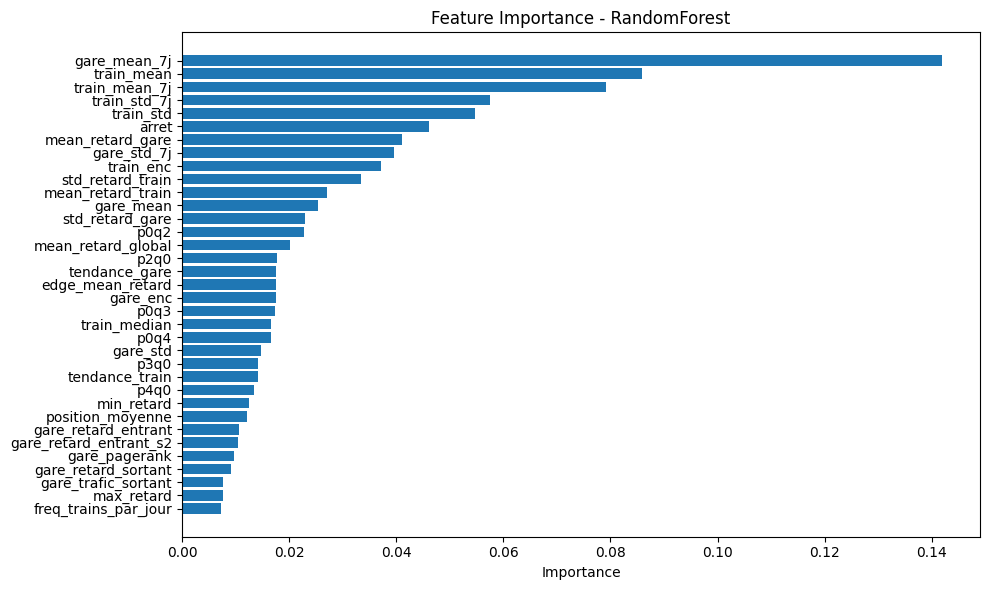

In [9]:
# Feature Importance
feature_importance = pd.DataFrame({
    'feature': FEATURES,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n--- Feature Importance ---")
print(feature_importance)

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Importance')
plt.title('Feature Importance - RandomForest')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=100, bbox_inches='tight')
plt.show()

In [10]:
# Pas de filtrage de features — on garde toutes les features
print(f"Utilisation de {len(FEATURES)} features: {FEATURES}")

Utilisation de 35 features: ['arret', 'p2q0', 'p3q0', 'p4q0', 'p0q2', 'p0q3', 'p0q4', 'mean_retard_train', 'mean_retard_gare', 'mean_retard_global', 'std_retard_train', 'std_retard_gare', 'tendance_train', 'tendance_gare', 'max_retard', 'min_retard', 'train_enc', 'gare_enc', 'gare_mean', 'gare_std', 'train_mean', 'train_std', 'train_median', 'position_moyenne', 'freq_trains_par_jour', 'train_mean_7j', 'train_std_7j', 'gare_mean_7j', 'gare_std_7j', 'edge_mean_retard', 'gare_retard_entrant', 'gare_retard_sortant', 'gare_retard_entrant_s2', 'gare_trafic_sortant', 'gare_pagerank']


In [11]:
# Target encoding + rolling 7j sur TOUT le train, appliqué au train et au test
print("Computing final features...")
x_train_final = add_target_features(x_train_fe, x_train_fe, y)
x_test_final = add_target_features(x_test_fe, x_train_fe, y)

# Modèle final RF (paramètres par défaut comme le pote)
model_final = RandomForestRegressor(
    n_estimators=100,
    n_jobs=-1,
    random_state=42,
    verbose=1
)
model_final.fit(x_train_final[FEATURES], y)

pred_test = model_final.predict(x_test_final[FEATURES])

# Arrondi à l'entier
pred_test_rounded = np.round(pred_test).astype(int)

submission = pd.DataFrame({"p0q0": pred_test_rounded})
submission.to_csv("submission_v17_aligned.csv", index=True)

print(f"submission_v17_aligned.csv créé avec {len(submission)} lignes")
print(submission.head())
print(f"\nStats prédictions:\n{submission.describe()}")

Computing final features...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:   17.4s


submission_v17_aligned.csv créé avec 20657 lignes
   p0q0
0    -1
1     1
2     1
3     0
4    -1

Stats prédictions:
               p0q0
count  20657.000000
mean      -0.081232
std        0.872977
min       -3.000000
25%       -1.000000
50%        0.000000
75%        0.000000
max        3.000000


[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  1.4min finished
[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 100 out of 100 | elapsed:    0.0s finished


In [12]:
import torch
import keras

print(f"Keras version: {keras.__version__}")
print(f"Keras backend: {keras.backend.backend()}")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA disponible: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'Aucun'}")

Keras version: 3.14.0
Keras backend: tensorflow
PyTorch version: 2.11.0+cu128
CUDA disponible: True
GPU: NVIDIA GeForce RTX 5070 Ti Laptop GPU


In [13]:
import keras
from keras.layers import Dense, BatchNormalization, Dropout, Input
from sklearn.preprocessing import RobustScaler, StandardScaler

# ===== Features NN : retirer les 5 features train_* (NaN 99.99% du test) =====
NN_FEATURES = [f for f in FEATURES if f not in
               ["train_mean", "train_std", "train_median", "train_mean_7j", "train_std_7j"]]
print(f"NN: {len(NN_FEATURES)} features (retirées: train_mean/std/median/7j)")

# ===== Préparer X avec x_tr/x_val (split 90/10, target encoding SANS leakage) =====
X_nn_tr  = x_tr[NN_FEATURES].replace([np.inf, -np.inf], np.nan).fillna(0).values.astype(np.float32)
X_nn_val = x_val[NN_FEATURES].replace([np.inf, -np.inf], np.nan).fillna(0).values.astype(np.float32)

# Scaler X
scaler_X = RobustScaler()
X_nn_tr  = np.clip(scaler_X.fit_transform(X_nn_tr), -10, 10).astype(np.float32)
X_nn_val = np.clip(scaler_X.transform(X_nn_val), -10, 10).astype(np.float32)

# Scaler y (CRUCIAL — le NN prédit en espace normalisé)
scaler_y = StandardScaler()
y_tr_s = scaler_y.fit_transform(y_tr.values.reshape(-1, 1)).astype(np.float32)
y_val_s = scaler_y.transform(y_val.values.reshape(-1, 1)).astype(np.float32)

print(f"y scaled range: [{y_tr_s.min():.1f}, {y_tr_s.max():.1f}]")

# ===== MLP =====
n = len(NN_FEATURES)
inp = Input(shape=(n,))
x = Dense(256, activation="relu")(inp)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation="relu")(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
x = Dense(64, activation="relu")(x)
x = BatchNormalization()(x)
x = Dense(32, activation="relu")(x)
x = Dense(1)(x)

model_nn = keras.Model(inp, x)
model_nn.compile(optimizer=keras.optimizers.Adam(1e-3), loss=keras.losses.Huber(delta=1.0), metrics=["mae"])
model_nn.summary()

history = model_nn.fit(
    X_nn_tr, y_tr_s,
    validation_data=(X_nn_val, y_val_s),
    epochs=200, batch_size=1024,
    callbacks=[
        keras.callbacks.ReduceLROnPlateau("val_mae", factor=0.5, patience=10, min_lr=1e-6, verbose=1),
        keras.callbacks.EarlyStopping("val_mae", patience=30, restore_best_weights=True, verbose=1)
    ],
    verbose=1
)

# ===== MAE réelle =====
pred_nn_val = scaler_y.inverse_transform(model_nn.predict(X_nn_val)).flatten()
pred_rf_val = model.predict(x_val[FEATURES])
mae_nn = mean_absolute_error(y_val, pred_nn_val)
mae_rf = mean_absolute_error(y_val, pred_rf_val)

print(f"\n{'='*40}")
print(f"MAE RF:  {mae_rf:.4f}")
print(f"MAE NN:  {mae_nn:.4f}")
print(f"{'='*40}")

# Meilleur alpha ensemble
best_alpha, best_mae = 0, 999
for a in np.arange(0, 1.01, 0.05):
    mix = a * pred_nn_val + (1 - a) * pred_rf_val
    m = mean_absolute_error(y_val, mix)
    if m < best_mae:
        best_alpha, best_mae = a, m
print(f"Meilleur ensemble: {best_alpha:.0%} NN + {1-best_alpha:.0%} RF → MAE val={best_mae:.4f}")

NN: 30 features (retirées: train_mean/std/median/7j)
y scaled range: [-80.9, 7.7]


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │         7,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,993 (207.00 KB)

 Trainable params: 52,097 (203.50 KB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/200
587/587 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.1706 - mae: 0.4218 - val_loss: 0.1481 - val_mae: 0.3806 - learning_rate: 0.0010
Epoch 2/200
587/587 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.1513 - mae: 0.3881 - val_loss: 0.1432 - val_mae: 0.3720 - learning_rate: 0.0010
Epoch 3/200
587/587 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.1474 - mae: 0.3804 - val_loss: 0.1412 - val_mae: 0.3696 - learning_rate: 0.0010
Epoch 4/200
587/587 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.1449 - mae: 0.3760 - val_loss: 0.1391 - val_mae: 0.3639 - learning_rate: 0.0010
Epoch 5/200
587/587 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.1432 - mae: 0.3727 - val_loss: 0.1379 - val_mae: 0.3618 - learning_rate: 0.0010
Epoch 6/200
587/587 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.1420 - mae: 0.3704 - val_loss: 0.1365 - val_mae: 0.3595 - learning_rate: 0.0010
Epoch 7/200
587/587 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.1410 - mae: 0.3685 - val_loss: 0.1360 - val_mae: 0.3595 - learning_rate: 0.0010

[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.1s



MAE RF:  0.7453
MAE NN:  0.6840
Meilleur ensemble: 80% NN + 20% RF → MAE val=0.6787


[Parallel(n_jobs=20)]: Done 100 out of 100 | elapsed:    0.8s finished


In [14]:
# ===== Soumission NN + Ensemble =====

# Prédiction test avec model_nn (early stopped, 30 features)
X_test_nn = x_test_final[NN_FEATURES].replace([np.inf, -np.inf], np.nan).fillna(0).values.astype(np.float32)
X_test_nn_s = np.clip(scaler_X.transform(X_test_nn), -10, 10).astype(np.float32)

# Check val
pred_check = scaler_y.inverse_transform(model_nn.predict(X_nn_val)).flatten()
print(f"Check MAE val NN: {mean_absolute_error(y_val, pred_check):.4f}")

# NaN check
nan_test = x_test_final[NN_FEATURES].isna().sum().sum()
print(f"NaN dans x_test[NN_FEATURES]: {nan_test}")

# Prédiction NN
pred_nn_test = scaler_y.inverse_transform(model_nn.predict(X_test_nn_s)).flatten()

# Prédiction RF (model_final entraîné sur 100%)
pred_rf_test = model_final.predict(x_test_final[FEATURES])

# === Soumission NN pure ===
submission_nn = pd.DataFrame({"p0q0": np.round(pred_nn_test).astype(int)})
submission_nn.to_csv("submission_nn_test2.csv", index=True)
print(f"\n--- NN pur ---")
print(f"Stats: mean={pred_nn_test.mean():.2f}, std={pred_nn_test.std():.2f}, min={pred_nn_test.min():.2f}, max={pred_nn_test.max():.2f}")

# === Soumission Ensemble optimal ===
pred_best = best_alpha * pred_nn_test + (1 - best_alpha) * pred_rf_test
sub_best = pd.DataFrame({"p0q0": np.round(pred_best).astype(int)})
sub_best.to_csv("submission_ensemble_test2.csv", index=True)
print(f"\n--- Ensemble {best_alpha:.0%} NN + {1-best_alpha:.0%} RF ---")
print(f"Stats: mean={pred_best.mean():.2f}, std={pred_best.std():.2f}")
print(f"\n{sub_best.describe()}")

2086/2086 ━━━━━━━━━━━━━━━━━━━━ 1s 413us/step
Check MAE val NN: 0.6840
NaN dans x_test[NN_FEATURES]: 0
646/646 ━━━━━━━━━━━━━━━━━━━━ 0s 469us/step


[Parallel(n_jobs=20)]: Using backend ThreadingBackend with 20 concurrent workers.
[Parallel(n_jobs=20)]: Done  10 tasks      | elapsed:    0.0s
[Parallel(n_jobs=20)]: Done 100 out of 100 | elapsed:    0.1s finished



--- NN pur ---
Stats: mean=-0.14, std=0.92, min=-16.16, max=2.93

--- Ensemble 80% NN + 20% RF ---
Stats: mean=-0.13, std=0.88

               p0q0
count  20657.000000
mean      -0.116716
std        0.914097
min      -13.000000
25%       -1.000000
50%        0.000000
75%        0.000000
max        3.000000
